## Import libraries


In [1]:
import os
from glob import glob

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from scipy.stats import linregress
from tqdm.auto import tqdm
from pathlib import Path
import xarray as xr
from scipy.stats import ks_2samp

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

import warnings

warnings.filterwarnings("ignore")

WORK_DIR = Path("/beegfs/halder/GITHUB/RESEARCH/AgroForecast-DE/")
os.chdir(WORK_DIR)

## Read the shapefile


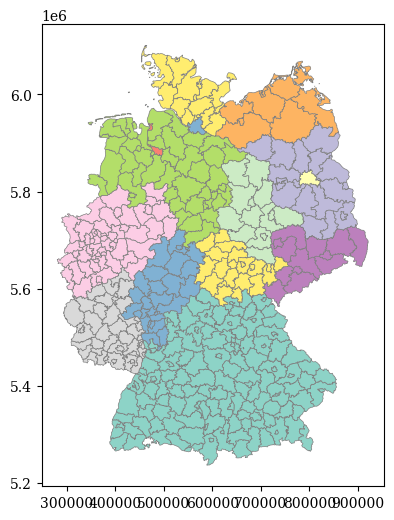

(400, 5)


,NUTS3_ID,NUTS3_NAME,NUTS1_ID,NUTS1_NAME,geometry
0,DE11B,Main-Tauber-Kreis,DE1,Baden-Württemberg,"MULTIPOLYGON (((546793.49 5514433.543, 546531...."
1,DE11C,Heidenheim,DE1,Baden-Württemberg,"MULTIPOLYGON (((585299.35 5401977.751, 585395...."
2,DE11D,Ostalbkreis,DE1,Baden-Württemberg,"MULTIPOLYGON (((591812.28 5434830.278, 591515...."
3,DE121,"Baden-Baden, Stadtkreis",DE1,Baden-Württemberg,"MULTIPOLYGON (((440009.175 5410196.803, 441490..."
4,DE122,"Karlsruhe, Stadtkreis",DE1,Baden-Württemberg,"MULTIPOLYGON (((458238.847 5435551.545, 459823..."


In [2]:
# Read the districts shapefile for DE
districts_gdf = gpd.read_file(
    os.path.join(WORK_DIR, "data", "raw", "districts", "districts.gpkg")
)

fig, ax = plt.subplots(figsize=(6, 6))
districts_gdf.plot(
    ax=ax,
    column="NUTS1_ID",
    cmap="Set3",
    edgecolor="grey",
    linewidth=0.5,
    label="NUTS3",
)
plt.show()

print(districts_gdf.shape)
districts_gdf.head()

## Read the climate data


In [3]:
district_id = "DE118"
ensemble_member = 20

observed = pd.read_parquet(
    WORK_DIR / "data" / "interim" / "climate" / "districts" / f"{district_id}.parquet"
)
observed["remark"] = "observed"
observed["date"] = pd.to_datetime(observed["date"], format="%Y-%m-%d")
observed = observed[observed["date"] < "2026-04-01"]

forecast = pd.read_parquet(
    WORK_DIR
    / "data"
    / "interim"
    / "gcfs22"
    / "sfc20260401"
    / f"r{ensemble_member}i1p1"
    / f"{district_id}.parquet"
)
forecast["remark"] = "forecast"
forecast["date"] = pd.to_datetime(forecast["date"], format="%Y-%m-%d")

print(observed.shape, forecast.shape)

(9587, 15) (184, 15)


## Compare the distribuition in observed and forecast data


Filtering observed data to match forecast months: [ 4  5  6  7  8  9 10]
Generating visual distributions...


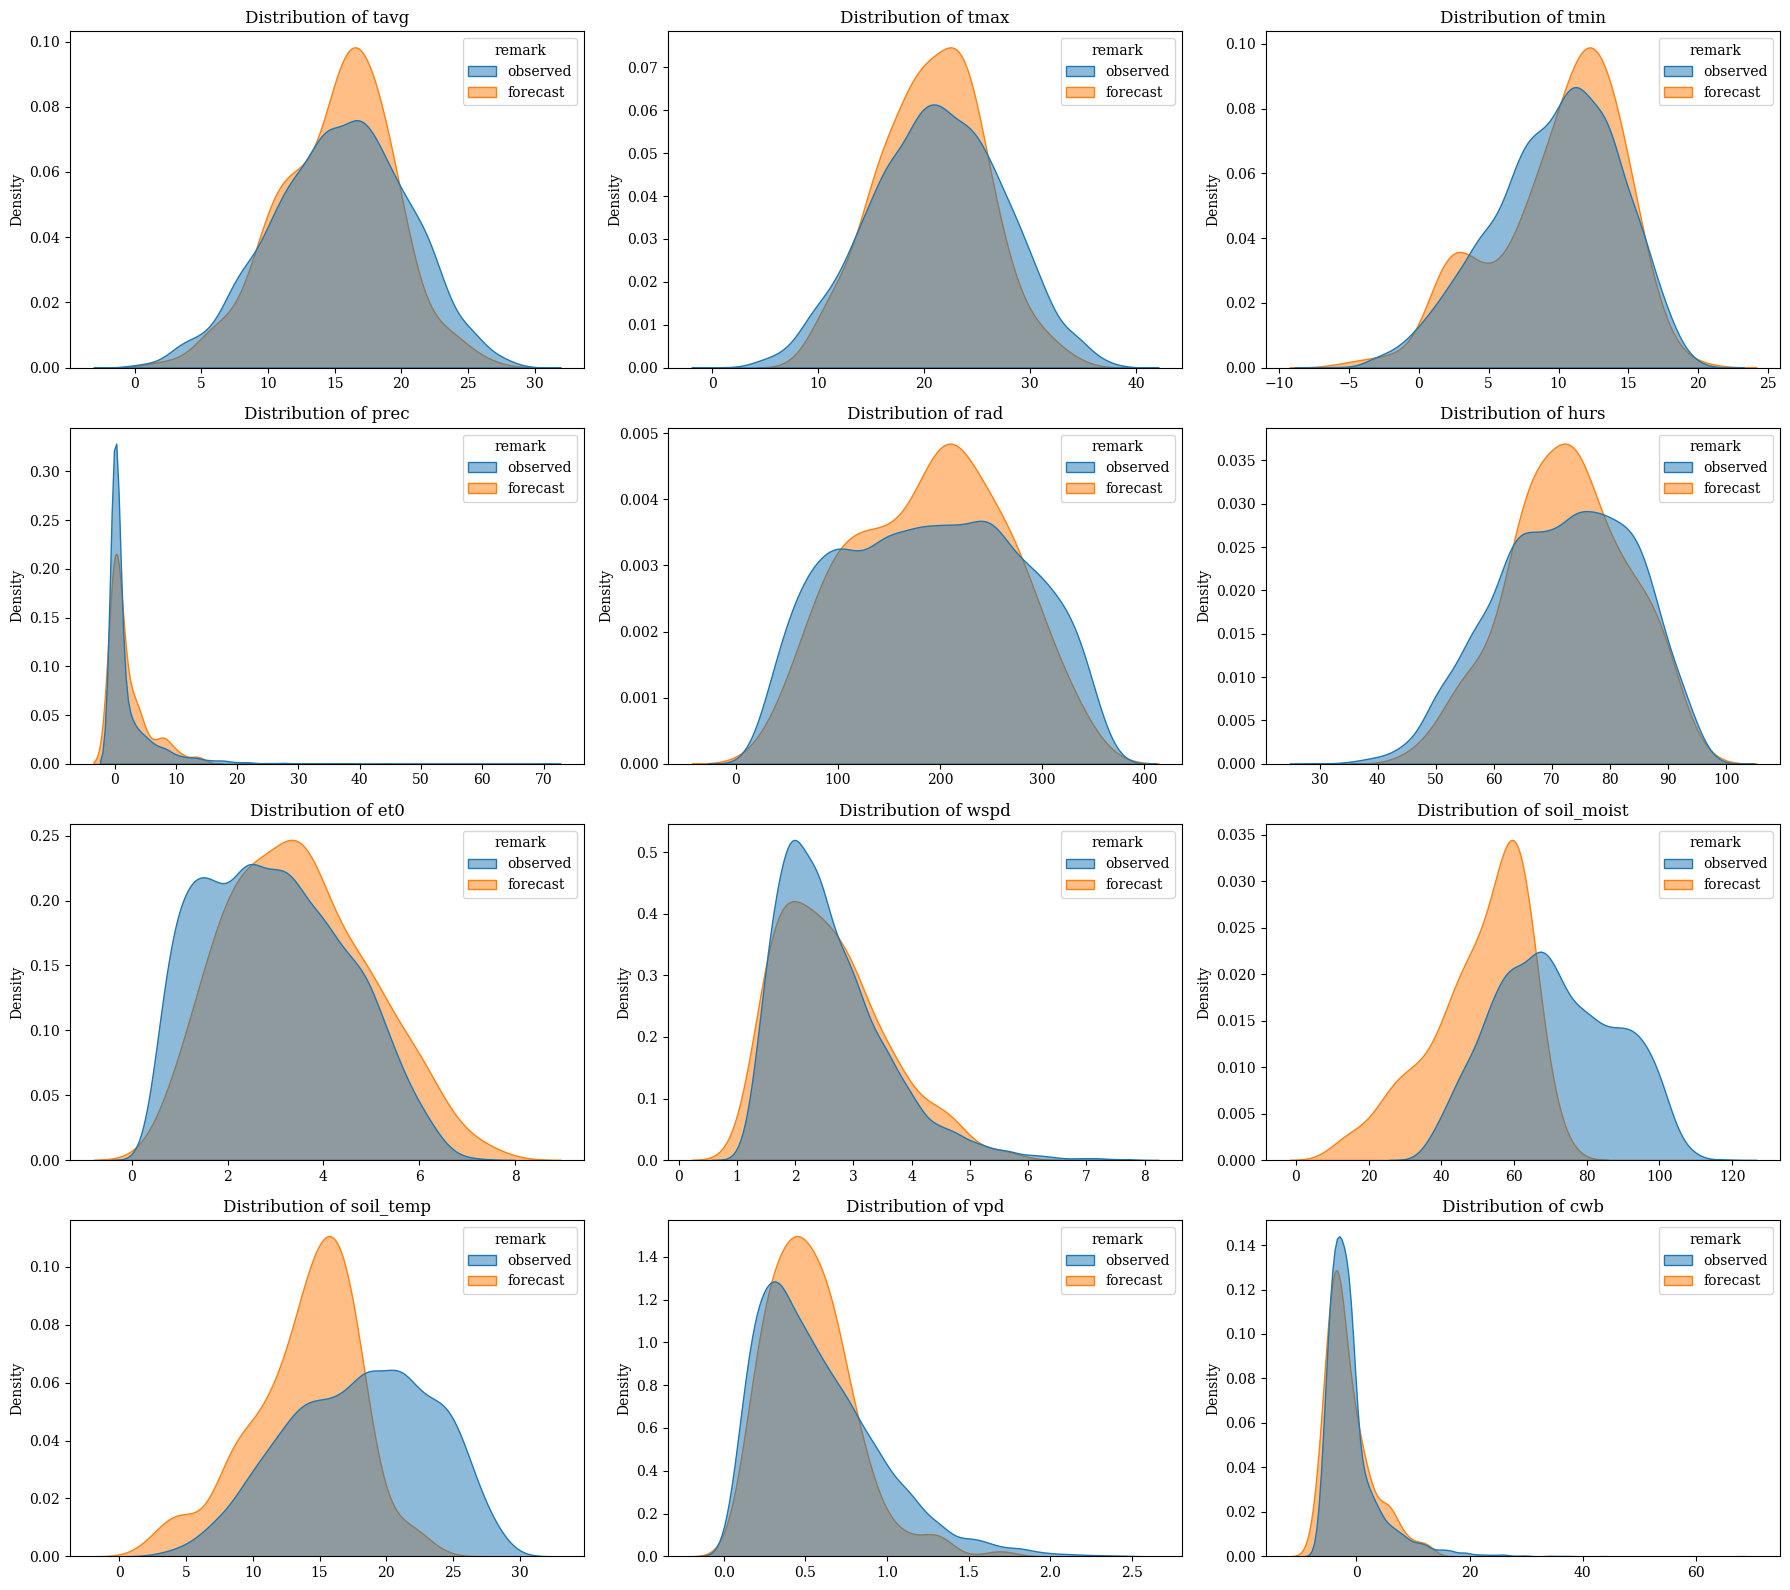


Kolmogorov-Smirnov Test Results (Alpha = 0.05)
---------------------------------------------------------------------------
Variable        | KS Statistic    | p-value         | Distributions Match?
---------------------------------------------------------------------------
tavg            | 0.1054          | 3.5294e-02      | No (Different)      
tmax            | 0.1167          | 1.4253e-02      | No (Different)      
tmin            | 0.0964          | 6.8059e-02      | Yes (Similar)       
prec            | 0.1050          | 3.6432e-02      | No (Different)      
rad             | 0.0752          | 2.5297e-01      | Yes (Similar)       
hurs            | 0.0965          | 6.7598e-02      | Yes (Similar)       
et0             | 0.1412          | 1.4566e-03      | No (Different)      
wspd            | 0.0501          | 7.4368e-01      | Yes (Similar)       
soil_moist      | 0.5547          | 6.1067e-52      | No (Different)      
soil_temp       | 0.4487          | 3.5348e-33    

In [ ]:
# 1. Combine the datasets
forecast_months = forecast["date"].dt.month.unique()
print(f"Filtering observed data to match forecast months: {forecast_months}")
observed = observed[observed["date"].dt.month.isin(forecast_months)]
df_combined = pd.concat([observed, forecast], ignore_index=True)

# 2. Identify variables to compare (excluding metadata)
exclude_cols = ['date', 'district_id', 'remark']
variables = [col for col in observed.columns if col not in exclude_cols]

print("Generating visual distributions...")
# Calculate grid size for subplots
num_vars = len(variables)
cols = 3
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.kdeplot(
        data=df_combined, 
        x=var, 
        hue='remark', 
        fill=True, 
        ax=axes[i], 
        common_norm=False,
        alpha=0.5
    )
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel('')

# Clean up empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Statistical Comparison (KS-Test)
# The Kolmogorov-Smirnov test checks if two samples are drawn from the same continuous distribution.
# Null Hypothesis (H0): The distributions are the same.
# If p-value < 0.05, we reject H0 (they are statistically different).
print("\nKolmogorov-Smirnov Test Results (Alpha = 0.05)")
print("-" * 75)
print(f"{'Variable':<15} | {'KS Statistic':<15} | {'p-value':<15} | {'Distributions Match?':<20}")
print("-" * 75)

for var in variables:
    # Extract data and drop NaNs to prevent math errors
    data_observed = observed[var].dropna()
    data_forecast = forecast[var].dropna()
    
    # Run KS-Test
    stat, p_value = ks_2samp(data_observed, data_forecast)
    
    # Interpret results
    is_match = "No (Different)" if p_value < 0.05 else "Yes (Similar)"
    
    print(f"{var:<15} | {stat:<15.4f} | {p_value:<15.4e} | {is_match:<20}")
    
print("-" * 75)